## Introduction

In this project, we aim to predict medical insurance claim charges based on personal attributes such as age, BMI, smoking status, gender, number of children, and region.

This is a regression problem where the target variable (charges) is continuous. We use a Linear Regression model to understand how different factors influence insurance costs.

In [23]:
# importing libraries for data calculation,visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Importing function to split data
from sklearn.model_selection import train_test_split
# Importing Linear Regression model
from sklearn.linear_model import LinearRegression

In [24]:
#  Load Dataset
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance (1).csv


In [25]:
# Dateset overview mean printing first few row
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [26]:
# displaying  shape
print("Shape of dataset(mean row and columns):")
print(df.shape)
print("\n")
# displaying columns name
print("Columns of dataset:")
print(df.columns)
print("\n")
# displaying dataset information like datatype
print("Information of dataset:")
print(df.info())
print("\n")
# displaying statistical summary of numaerical columns
print("Statistical summary of numaerical columns:")
print(df.describe())

Shape of dataset(mean row and columns):
(1338, 7)


Columns of dataset:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


Information of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


Statistical summary of numaerical columns:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min     

In [27]:
# Check if any column has missing values
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


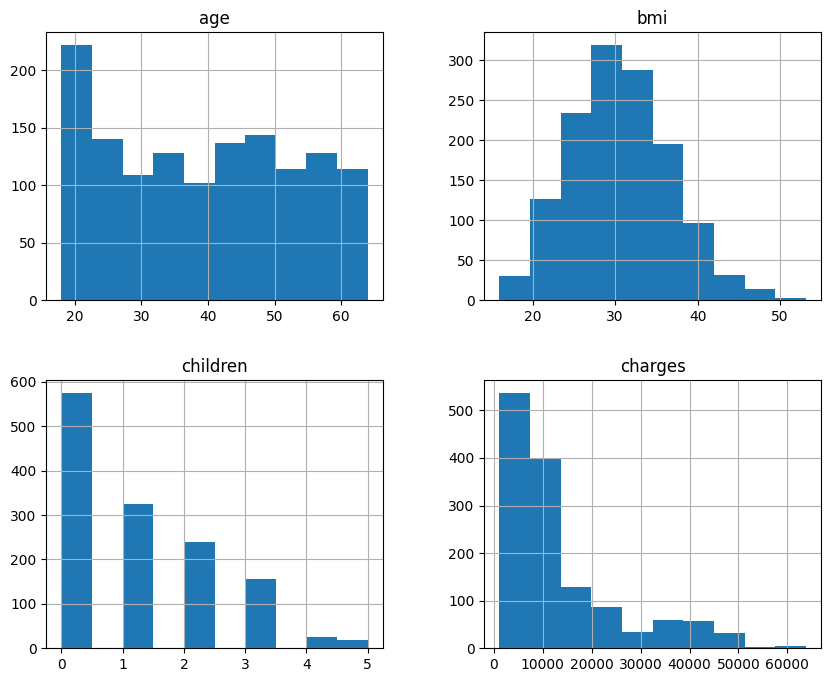

In [28]:
# Histogram of all numeric features
df.hist(figsize=(10,8))
plt.show()

In [29]:
# Converting  categorical columns (sex, smoker, region) into numerical form
# drop_first=True avoids dummy variable trap
df_encoded = pd.get_dummies(df, drop_first=True)

# Show transformed dataset
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [30]:
# x contains all input features except target
X = df_encoded.drop("charges", axis=1)

# y contains target variable (insurance cost)
y = df_encoded["charges"]

In [31]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# Creating model object
model = LinearRegression()

# Train model on training data
model.fit(X_train, y_train)

LinearRegression()

In [33]:
# Predicting insurance charges for test data
y_pred = model.predict(X_test)

In [34]:

# Calculating Mean Absolute Error (average error)
mae = mean_absolute_error(y_test, y_pred)

# Calculating Mean Squared Error and convert to RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Printing Final Results
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 4181.19447375365
Root Mean Squared Error (RMSE): 5796.284659276273


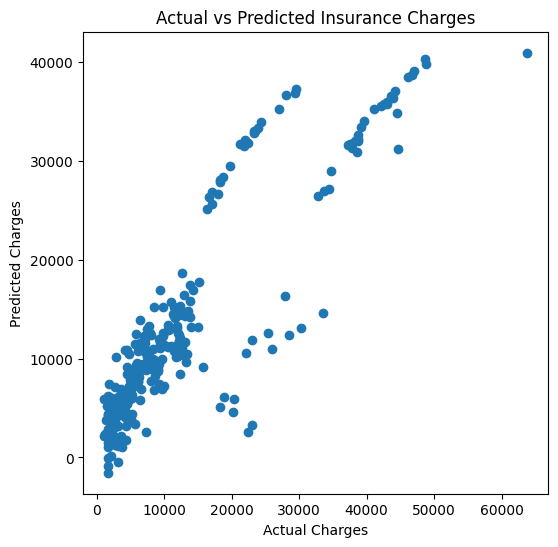

In [35]:
# Plot actual vs predicted values
plt.figure(figsize=(6,6))

# Scatter plot of actual vs predicted charges
plt.scatter(y_test, y_pred)

# Label x-axis
plt.xlabel("Actual Charges")

# Label y-axis
plt.ylabel("Predicted Charges")

# Title of graph
plt.title("Actual vs Predicted Insurance Charges")

# Show plot
plt.show()

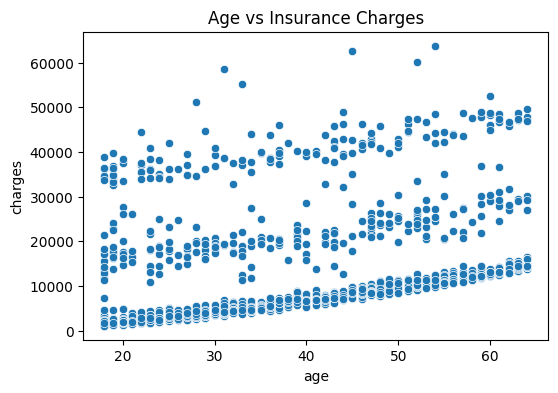

In [36]:
# Relationship between age and insurance cost
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age"], y=df["charges"])
plt.title("Age vs Insurance Charges")
plt.show()

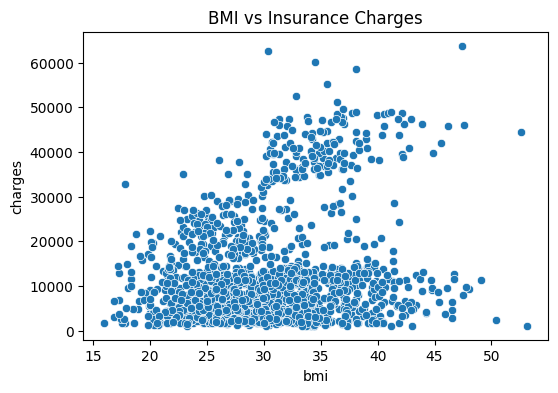

In [37]:
# Relationship between BMI and insurance cost
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["bmi"], y=df["charges"])
plt.title("BMI vs Insurance Charges")
plt.show()

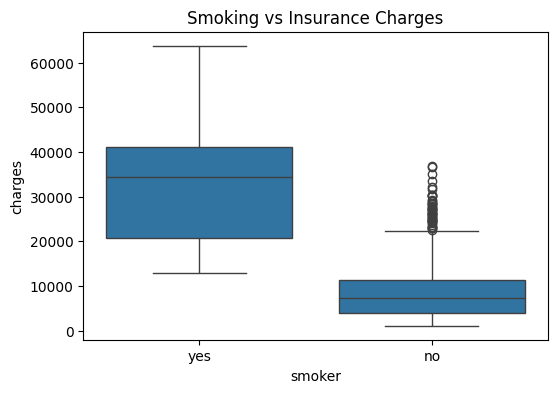

In [38]:
# Boxplot to show effect of smoking on charges
plt.figure(figsize=(6,4))
sns.boxplot(x=df["smoker"], y=df["charges"])
plt.title("Smoking vs Insurance Charges")
plt.show()

## What I Did

In this task, I performed the following steps:

- Loaded and explored the insurance dataset using pandas.
- Checked dataset structure, missing values, and statistical summary.
- Converted categorical variables into numerical format using one-hot encoding.
- Selected features (X) and target variable (y = charges).
- Split the dataset into training and testing sets using an 80/20 ratio.
- Trained a Linear Regression model on the training data.
- Made predictions on the test data.
- Evaluated the model using MAE and RMSE.
- Visualized relationships between features (age, BMI, smoking) and insurance charges.

## Conclusion

* Linear Regression was used to predict insurance claim charges
* Features like age, BMI, smoking status, and region were analyzed
* Smoking has the strongest impact on insurance charges
* Model performance: MAE = 4181, RMSE = 5796
* Actual vs predicted plot shows reasonable linear relationship